In [259]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns


# Exploratory Analysis

In [260]:
#import owid data - co2 emissions
#keep: everything
#---------

df = pd.read_csv("owid-co2-data.csv")

In [261]:
types = df.dtypes

print(f"dtype per column\n")
k = 3
for i, col_name in enumerate(df.columns):
    print(f"{str(col_name):<40}", f"{str(types[col_name]):<40}", end="\n" if (i+1)%k==0 else "")


dtype per column

country                                  object                                  year                                     int64                                   iso_code                                 object                                  
population                               float64                                 gdp                                      float64                                 cement_co2                               float64                                 
cement_co2_per_capita                    float64                                 co2                                      float64                                 co2_growth_abs                           float64                                 
co2_growth_prct                          float64                                 co2_including_luc                        float64                                 co2_including_luc_growth_abs             float64                                 
co2_in

In [262]:
check=["country", "year", "iso_code"]

print("number of unique values")
for c in check:
    print(f"{c:<20}", len(df[c].unique()))

number of unique values
country              254
year                 275
iso_code             219


In [263]:
# indexing
if {'country', 'year'}.issubset(df.columns):
    df = df.set_index(['country', 'year']).sort_index()

In [264]:
missing = np.sum(df.isna())/df.shape[0]

print(f"% of missing values for every column\n")
k = 3
for i, col_name in enumerate(df.columns):
    print(f"{str(col_name):<40}", f"{missing[col_name]:.2%}", 5*" ", end="\n" if (i+1)%k==0 else "")

% of missing values for every column

iso_code                                 15.73%      population                               18.34%      gdp                                      69.75%      
cement_co2                               42.13%      cement_co2_per_capita                    49.12%      co2                                      41.71%      
co2_growth_abs                           46.01%      co2_growth_prct                          47.95%      co2_including_luc                        52.80%      
co2_including_luc_growth_abs             53.39%      co2_including_luc_growth_prct            53.39%      co2_including_luc_per_capita             52.87%      
co2_including_luc_per_gdp                66.69%      co2_including_luc_per_unit_energy        80.12%      co2_per_capita                           47.41%      
co2_per_gdp                              65.23%      co2_per_unit_energy                      78.78%      coal_co2                                 56.51%      
co

c:\Users\vetle\anaconda3\envs\finance\Lib\site-packages\numpy\_core\fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [265]:
missing = np.sum(df.isna())/df.shape[0]

print(f"% of missing values for every co2-column\n")
k = 3
i = 0
min = 1
argmin = None

for col_name in df.columns:
    if "co2" in col_name.lower():
        print(f"{str(col_name):<40}", f"{missing[col_name]:.2%}", 5*" ", end="\n" if (i+1)%k==0 else "")
        if missing[col_name]<min:
            min = missing[col_name]
            argmin = col_name    
        i += 1

print("\n")
print("least missing", argmin, "value=", f"{min:.2%}", "\n")

% of missing values for every co2-column

cement_co2                               42.13%      cement_co2_per_capita                    49.12%      co2                                      41.71%      
co2_growth_abs                           46.01%      co2_growth_prct                          47.95%      co2_including_luc                        52.80%      
co2_including_luc_growth_abs             53.39%      co2_including_luc_growth_prct            53.39%      co2_including_luc_per_capita             52.87%      
co2_including_luc_per_gdp                66.69%      co2_including_luc_per_unit_energy        80.12%      co2_per_capita                           47.41%      
co2_per_gdp                              65.23%      co2_per_unit_energy                      78.78%      coal_co2                                 56.51%      
coal_co2_per_capita                      57.72%      consumption_co2                          89.98%      consumption_co2_per_capita               90.79%     

<Axes: title={'center': 'co2_per_gdp'}, ylabel='Density'>

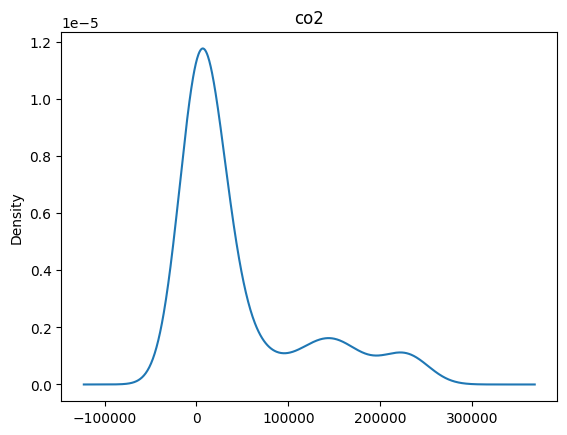

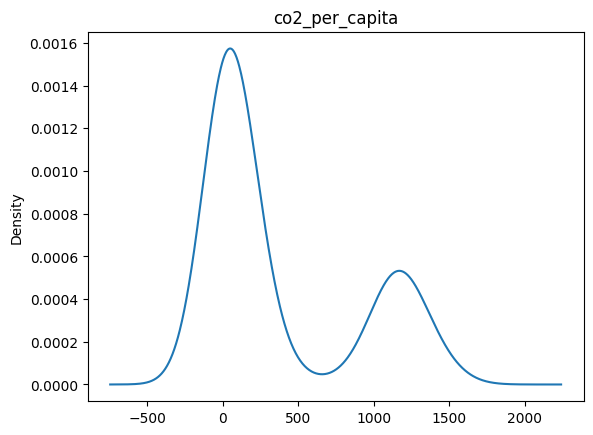

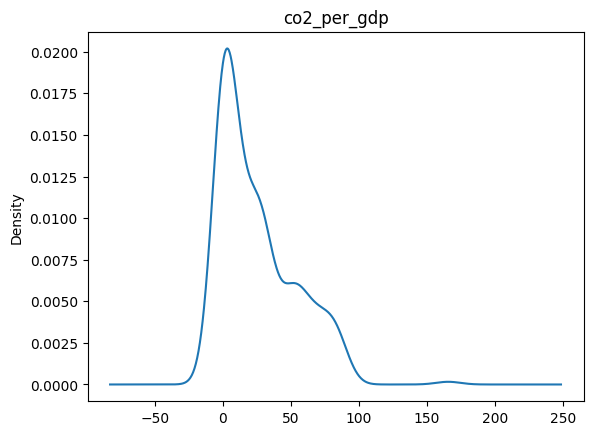

In [266]:
#visualize

grouped = df.groupby(level="year")
plt.figure()
plt.title("co2")
grouped.co2.sum().plot(kind="kde")
plt.figure()
plt.title("co2_per_capita")
grouped.co2_per_capita.sum().plot(kind="kde")
plt.figure()
plt.title("co2_per_gdp")
grouped.co2_per_gdp.sum().plot(kind="kde")


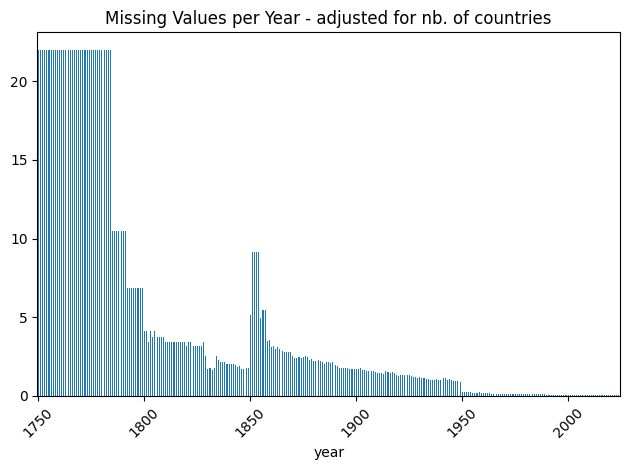

In [267]:
# ADJUST FOR NUMBER OF COUNTRIES - DONE


#missing co2-values per year
missing_per_year = df.isna().groupby(level=1)["co2"].sum()
countries_per_year = df.groupby(level=1)["co2"].nunique()
missing_per_year_adj = missing_per_year / countries_per_year

fig,ax = plt.subplots()
missing_per_year_adj.plot(kind="bar", title="Missing Values per Year - adjusted for nb. of countries", ax=ax)
ax.set_xticks(range(0, len(missing_per_year), 50))  # every 50th year
plt.xticks(rotation=45)
plt.tight_layout()

In [268]:
list = df.index.unique(level=0)
k = 7

for i, country in enumerate(list):
    print(f"{country:<30}", end="\n" if (i+1)%k==0 else "")


Afghanistan                   Africa                        Africa (GCP)                  Albania                       Algeria                       Andorra                       Angola                        
Anguilla                      Antarctica                    Antigua and Barbuda           Argentina                     Armenia                       Aruba                         Asia                          
Asia (GCP)                    Asia (excl. China and India)  Australia                     Austria                       Azerbaijan                    Bahamas                       Bahrain                       
Bangladesh                    Barbados                      Belarus                       Belgium                       Belize                        Benin                         Bermuda                       
Bhutan                        Bolivia                       Bonaire Sint Eustatius and SabaBosnia and Herzegovina        Botswana                      Brazi

In [269]:
treated_countries = [
    'Austria', 'Germany', 'Netherlands',
    'Belgium', 'Greece', 'Poland',
    'Cyprus', 'Hungary', 'Portugal',
    'Czech Republic', 'Ireland', 'Slovakia',
    'Denmark', 'Italy', 'Slovenia',
    'Estonia', 'Latvia', 'Spain',
    'Finland', 'Lithuania', 'Sweden',
    'France', 'Luxembourg'
]

control_countries = [
    'United States', 'India', 'Russia', 'Saudi Arabia', 'Brazil', 'Egypt',
    'Nigeria', 'Pakistan', 'Bangladesh', 'Ethiopia', 'Philippines', 'Vietnam',
    'Turkey', 'Argentina', 'Algeria', 'Iraq', 'Morocco', 'Peru', 'Uzbekistan',
    'Malaysia', 'Kenya', 'Ghana', 'Tanzania', 'Sri Lanka', 'Myanmar', 'Canada'
]

# treated_countries = ['Germany', 'United Kingdom', 'France']
# control_countries = ['United States', 'Russia', 'Brazil']

In [270]:
df_treated = df[df.index.get_level_values(0).isin(treated_countries)]
df_control = df[df.index.get_level_values(0).isin(control_countries)]

Countries in treated ['Austria', 'Germany', 'Netherlands', 'Belgium', 'Greece', 'Poland', 'Cyprus', 'Hungary', 'Portugal', 'Czech Republic', 'Ireland', 'Slovakia', 'Denmark', 'Italy', 'Slovenia', 'Estonia', 'Latvia', 'Spain', 'Finland', 'Lithuania', 'Sweden', 'France', 'Luxembourg']
Countries in control ['United States', 'India', 'Russia', 'Saudi Arabia', 'Brazil', 'Egypt', 'Nigeria', 'Pakistan', 'Bangladesh', 'Ethiopia', 'Philippines', 'Vietnam', 'Turkey', 'Argentina', 'Algeria', 'Iraq', 'Morocco', 'Peru', 'Uzbekistan', 'Malaysia', 'Kenya', 'Ghana', 'Tanzania', 'Sri Lanka', 'Myanmar', 'Canada']


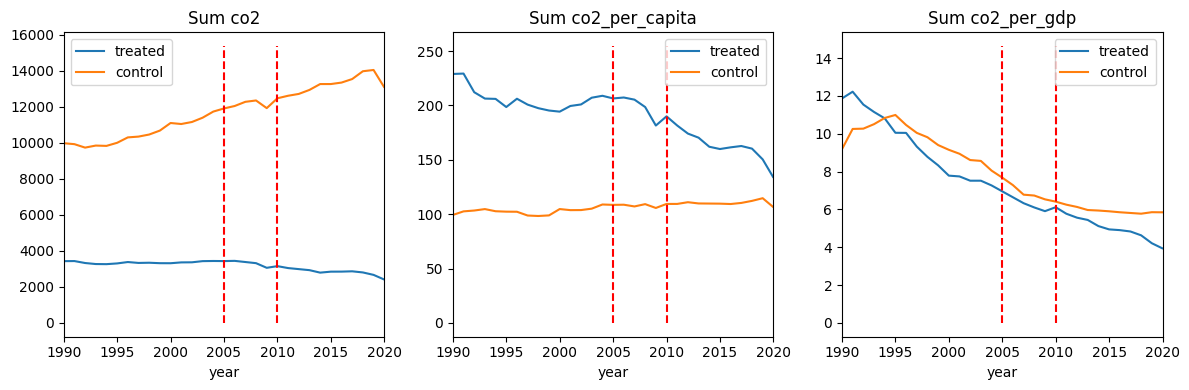

In [271]:
print("Countries in treated", treated_countries)
print("Countries in control", control_countries)


fig, axs = plt.subplots(1,3, figsize=(12, 4))

for i, col in enumerate(["co2", "co2_per_capita", "co2_per_gdp"]):
    ax = axs[i]
    df_treated.groupby(level=1)[col].sum().plot(label="treated", ax=ax)
    df_control.groupby(level=1)[col].sum().plot(label="control", ax=ax)
    ax.set_title(f"Sum {col}")
    ax.set_xlim(1990, 2020)
    m = ax.get_ylim()[1]
    ax.vlines(x=2005, ymin=0, ymax=m, color="red", linestyle="dashed")
    ax.vlines(x=2010, ymin=0, ymax=m, color="red", linestyle="dashed")
    ax.legend()
    
plt.tight_layout()
plt.show()




# Difference-in-differences

## Creating data set

In [272]:
#showing the variables
list = df.columns.to_list()
k = 4

for i, country in enumerate(list):
    print(f"{country:<40}", end="\n" if (i+1)%k==0 else "")


iso_code                                population                              gdp                                     cement_co2                              
cement_co2_per_capita                   co2                                     co2_growth_abs                          co2_growth_prct                         
co2_including_luc                       co2_including_luc_growth_abs            co2_including_luc_growth_prct           co2_including_luc_per_capita            
co2_including_luc_per_gdp               co2_including_luc_per_unit_energy       co2_per_capita                          co2_per_gdp                             
co2_per_unit_energy                     coal_co2                                coal_co2_per_capita                     consumption_co2                         
consumption_co2_per_capita              consumption_co2_per_gdp                 cumulative_cement_co2                   cumulative_co2                          
cumulative_co2_including_luc      

In [273]:
"primary_energy_consumption" in df.columns.to_list()

True

In [274]:
df_did = df[["co2", "gdp", "population", "primary_energy_consumption"]]

In [275]:
df_did = df_did.rename(columns={"primary_energy_consumption": "energy"})

In [276]:
#removing other countries
df_did = df_did[df_did.index.get_level_values(level=0).isin(treated_countries+control_countries)]

df_did["treated"] = df_did.index.get_level_values(level=0).isin(treated_countries)
df_did["post_treatment"] = (df_did.index.get_level_values(level=1) >= 2005)


In [277]:
df_did

co2           gdp   population    energy  treated  \
country year                                                          
Algeria 1850      NaN           NaN    2852648.0       NaN    False   
        1851      NaN           NaN    2872405.0       NaN    False   
        1852      NaN           NaN    2897058.0       NaN    False   
        1853      NaN           NaN    2926664.0       NaN    False   
        1854      NaN           NaN    2956573.0       NaN    False   
...               ...           ...          ...       ...      ...   
Vietnam 2020  362.599  7.526296e+11   98079196.0  1228.728    False   
        2021  314.197  7.719120e+11   98935101.0  1223.385    False   
        2022  322.653  8.338039e+11   99680656.0  1293.495    False   
        2023  347.399           NaN  100352189.0  1375.936    False   
        2024  370.931           NaN  100987685.0  1476.252    False   

              post_treatment  
country year                  
Algeria 1850           False  
        1851           False  
        1852           False  
        1853           False  
        1854           False  
...                      ...  
Vietnam 2020            True  
        2021            True  
        2022            True  
        2023            True  
        2024            True  

[9295 rows x 6 columns]

In [278]:
#formatting
df_did["treated"] = df_did["treated"].astype(int)
df_did["post_treatment"] = df_did["post_treatment"].astype(int)

In [279]:
df_did

co2           gdp   population    energy  treated  \
country year                                                          
Algeria 1850      NaN           NaN    2852648.0       NaN        0   
        1851      NaN           NaN    2872405.0       NaN        0   
        1852      NaN           NaN    2897058.0       NaN        0   
        1853      NaN           NaN    2926664.0       NaN        0   
        1854      NaN           NaN    2956573.0       NaN        0   
...               ...           ...          ...       ...      ...   
Vietnam 2020  362.599  7.526296e+11   98079196.0  1228.728        0   
        2021  314.197  7.719120e+11   98935101.0  1223.385        0   
        2022  322.653  8.338039e+11   99680656.0  1293.495        0   
        2023  347.399           NaN  100352189.0  1375.936        0   
        2024  370.931           NaN  100987685.0  1476.252        0   

              post_treatment  
country year                  
Algeria 1850               0  
        1851               0  
        1852               0  
        1853               0  
        1854               0  
...                      ...  
Vietnam 2020               1  
        2021               1  
        2022               1  
        2023               1  
        2024               1  

[9295 rows x 6 columns]

In [280]:
#aggregating two groups: [["co2", "gdp", "energy", "capita", "treated", "post_treatment"]] 
df_did_agg = df_did.groupby(["year", "country"]).agg({
    "co2": "sum", 
    "gdp": "sum", 
    "energy": "sum", 
    "population": "sum",
    "post_treatment": "first",
    "treated": "first"
    }).reset_index()


In [281]:
df_did_agg

,year,country,co2,gdp,energy,population,post_treatment,treated
0,1750,Bangladesh,0.000,0.0,0.000,17095576.0,0,0
1,1750,Cyprus,0.000,0.0,0.000,110000.0,0,1
2,1750,Ethiopia,0.000,0.0,0.000,2611695.0,0,0
3,1750,Ghana,0.000,0.0,0.000,2340629.0,0,0
4,1750,Netherlands,0.000,0.0,0.000,2163333.0,0,1
...,...,...,...,...,...,...,...,...
9290,2024,Tanzania,20.018,0.0,0.000,68560162.0,1,0
9291,2024,Turkey,513.035,0.0,2093.058,87473800.0,1,0
9292,2024,United States,4904.120,0.0,26528.611,345426566.0,1,0
9293,2024,Uzbekistan,139.234,0.0,695.576,36361859.0,1,0


In [282]:
df_did_agg["treated"] = df_did_agg["treated"].astype(int)
df_did_agg["post_treatment"] = df_did_agg["post_treatment"].astype(int)
df_did_agg["co2"] = df_did_agg["co2"].astype(float)
df_did_agg["gdp"] = df_did_agg["gdp"].astype(float)
df_did_agg["energy"] = df_did_agg["energy"].astype(float)
df_did_agg["population"] = df_did_agg["population"].astype(float)
df_did_agg["year"] = df_did_agg["year"].astype(int)
df_did_agg["country"] = df_did_agg["country"].astype('category')

In [283]:
#creating logarithmic variables
df_did_agg["log_co2"] = np.log1p(df_did_agg["co2"])
df_did_agg["log_gdp"] = np.log1p(df_did_agg["gdp"])
df_did_agg["log_population"] = np.log1p(df_did_agg["population"])
df_did_agg["log_energy"] = np.log1p(df_did_agg["energy"])

In [284]:
df_did_agg_2 = df_did_agg.groupby(["year", "treated"]).agg({
    "co2": "sum",
    "energy": "sum",
    "gdp": "sum",
    "population": "sum",
    "post_treatment": "first",
})
df_did_agg_2 = df_did_agg_2.reset_index()
df_did_agg_2 = df_did_agg_2.set_index('year')

In [285]:
df_did_agg_2

,treated,co2,energy,gdp,population,post_treatment
year,,,,,,
1750,0,0.000,0.000,0.000000e+00,2.204790e+07,0
1750,1,0.000,0.000,0.000000e+00,2.273333e+06,0
1751,0,0.000,0.000,0.000000e+00,0.000000e+00,0
1751,1,0.000,0.000,0.000000e+00,0.000000e+00,0
1752,0,0.000,0.000,0.000000e+00,0.000000e+00,0
...,...,...,...,...,...,...
2022,1,2502.427,14980.946,1.598083e+13,4.080124e+08,1
2023,0,14361.050,69375.964,0.000000e+00,3.915251e+09,1
2023,1,2279.161,14582.833,0.000000e+00,4.095046e+08,1


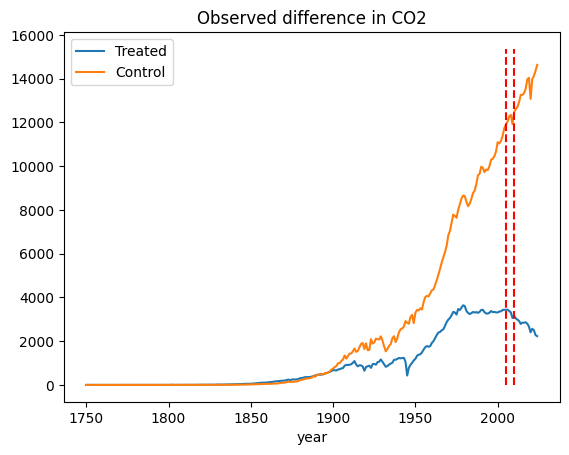

In [286]:
fig,ax = plt.subplots()
ax.set_title("Observed difference in CO2")
df_did_agg_2.loc[df_did_agg_2["treated"] == 1, "co2"].plot(kind="line", label="Treated", ax=ax)
df_did_agg_2.loc[df_did_agg_2["treated"] == 0, "co2"].plot(kind="line", label="Control", ax=ax)
ax.vlines([2005, 2010], ymin=0, ymax=ax.get_ylim()[1], color="red", linestyles="dashed")
plt.legend()

In [287]:
#testing for coherency
print("Number of years:", df_did_agg_2.index.nunique())
print("Number of rows (should be", 2*df_did_agg_2.index.nunique(), "): ", len(df_did_agg_2))

Number of years: 275
Number of rows (should be 550 ):  550


********************
Numer of zero years gdp: [1750, 1750, 1751, 1751, 1752, 1752, 1753, 1753, 1754, 1754, 1755, 1755, 1756, 1756, 1757, 1757, 1758, 1758, 1759, 1759, 1760, 1760, 1761, 1761, 1762, 1762, 1763, 1763, 1764, 1764, 1765, 1765, 1766, 1766, 1767, 1767, 1768, 1768, 1769, 1769, 1770, 1770, 1771, 1771, 1772, 1772, 1773, 1773, 1774, 1774, 1775, 1775, 1776, 1776, 1777, 1777, 1778, 1778, 1779, 1779, 1780, 1780, 1781, 1781, 1782, 1782, 1783, 1783, 1784, 1784, 1785, 1785, 1786, 1786, 1787, 1787, 1788, 1788, 1789, 1789, 1790, 1790, 1791, 1791, 1792, 1792, 1793, 1793, 1794, 1794, 1795, 1795, 1796, 1796, 1797, 1797, 1798, 1798, 1799, 1799, 1800, 1800, 1801, 1801, 1802, 1802, 1803, 1803, 1804, 1804, 1805, 1805, 1806, 1806, 1807, 1807, 1808, 1808, 1809, 1809, 1810, 1810, 1811, 1811, 1812, 1812, 1813, 1813, 1814, 1814, 1815, 1815, 1816, 1816, 1817, 1817, 1818, 1818, 1819, 1819, 2023, 2023, 2024, 2024]
********************

********************
Numer of zero years energy: [1750, 1750, 1751,

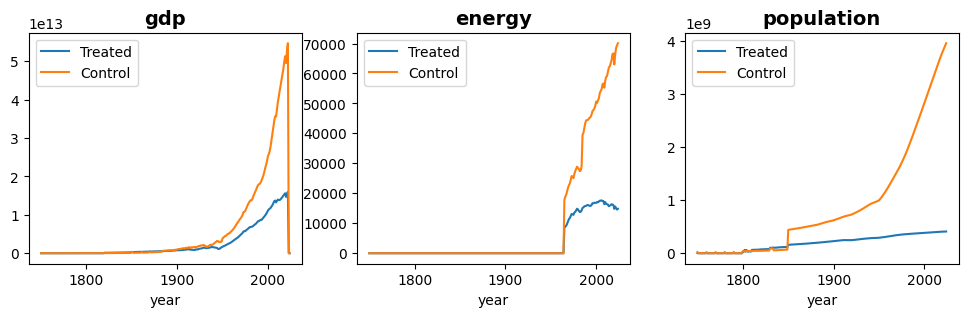

In [305]:
numerics = ["gdp", "energy", "population"]
fig,axs = plt.subplots(1,3, figsize=(12, 3))

for i, col in enumerate(numerics):
    ax = axs[i]
    df_did_agg_2.loc[df_did_agg_2["treated"] == 1, col].plot(kind="line", label="Treated", ax=ax)
    df_did_agg_2.loc[df_did_agg_2["treated"] == 0, col].plot(kind="line", label="Control", ax=ax)
    ax.set_title(col, fontsize=14, fontweight='bold')
    ax.legend(loc="upper left")
    print(20*"*")
    print(f"Numer of zero years {col}: {df_did_agg_2.loc[df_did_agg_2[col]==0].index.to_list()}")
    print(20*"*"+"\n")
    

In [289]:
df_did_agg

,year,country,co2,gdp,energy,population,post_treatment,treated,log_co2,log_gdp,log_population,log_energy
0,1750,Bangladesh,0.000,0.0,0.000,17095576.0,0,0,0.000000,0.0,16.654330,0.000000
1,1750,Cyprus,0.000,0.0,0.000,110000.0,0,1,0.000000,0.0,11.608245,0.000000
2,1750,Ethiopia,0.000,0.0,0.000,2611695.0,0,0,0.000000,0.0,14.775510,0.000000
3,1750,Ghana,0.000,0.0,0.000,2340629.0,0,0,0.000000,0.0,14.665931,0.000000
4,1750,Netherlands,0.000,0.0,0.000,2163333.0,0,1,0.000000,0.0,14.587161,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
9290,2024,Tanzania,20.018,0.0,0.000,68560162.0,1,0,3.045379,0.0,18.043222,0.000000
9291,2024,Turkey,513.035,0.0,2093.058,87473800.0,1,0,6.242291,0.0,18.286850,7.646859
9292,2024,United States,4904.120,0.0,26528.611,345426566.0,1,0,8.498035,0.0,19.660291,10.186017
9293,2024,Uzbekistan,139.234,0.0,695.576,36361859.0,1,0,4.943312,0.0,17.409031,6.546177


In [290]:
years = np.arange(2005 - (2022-2005+1), 2023)
print(years)
mask = (2005 - (2022-2005+1) <= df_did_agg.year) & (df_did_agg.year <= 2022) 

[1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000
 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014
 2015 2016 2017 2018 2019 2020 2021 2022]


In [291]:
df_did_agg_masked = df_did_agg.loc[mask].reset_index(drop=True)
df_did_agg_masked

,year,country,co2,gdp,energy,population,post_treatment,treated,log_co2,log_gdp,log_population,log_energy
0,1987,Algeria,83.020,1.183212e+11,285.168,23443627.0,0,0,4.431055,25.496669,16.970109,5.656579
1,1987,Argentina,114.936,3.678936e+11,532.661,31291764.0,0,0,4.753038,26.631060,17.258866,6.279761
2,1987,Austria,57.407,1.849934e+11,334.019,7574314.0,0,1,4.067436,25.943586,15.840273,5.814187
3,1987,Bangladesh,11.800,9.966304e+10,57.985,104959291.0,0,0,2.549445,25.325061,18.469083,4.077283
4,1987,Belgium,102.592,2.445046e+11,578.680,9899150.0,0,1,4.640460,26.222500,16.107960,6.362476
...,...,...,...,...,...,...,...,...,...,...,...,...
1723,2022,Tanzania,19.702,1.982204e+11,76.824,64711822.0,1,0,3.030230,26.012645,17.985454,4.354450
1724,2022,Turkey,443.603,2.385996e+12,1969.050,87058469.0,1,0,6.097182,28.500638,18.282091,7.585814
1725,2022,United States,5055.403,1.949317e+13,26512.510,341534041.0,1,0,8.528411,30.601085,19.648958,10.185410
1726,2022,Uzbekistan,119.105,3.935725e+11,592.522,34938953.0,1,0,4.788366,26.698531,17.369113,6.386074


In [292]:
#descriptive statistiscs
df_did_agg_masked.describe()

,year,co2,gdp,energy,population,post_treatment,treated,log_co2,log_gdp,log_population,log_energy
count,1728.000000,1728.000000,1.728000e+03,1728.000000,1.728000e+03,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000
mean,2004.500000,308.442508,9.224114e+11,1468.036340,7.164562e+07,0.500000,0.458333,4.363818,26.391472,16.984715,5.905812
std,10.391302,836.033385,2.192328e+12,3821.050986,1.684920e+08,0.500145,0.498405,1.581115,1.480636,1.553632,1.644921
min,1987.000000,2.063000,8.435045e+09,0.000000,3.707890e+05,0.000000,0.000000,1.119395,22.855661,12.823391,0.000000
25%,1995.750000,21.850500,1.119563e+11,105.307250,9.796014e+06,0.000000,0.000000,3.128970,25.441372,16.097486,4.666332
50%,2004.500000,69.812000,2.644515e+11,341.144000,2.972874e+07,0.500000,0.000000,4.260028,26.300923,17.207625,5.835232
75%,2013.250000,222.336250,8.059457e+11,1046.690500,6.530722e+07,1.000000,1.000000,5.408665,27.415282,17.994613,6.954343
max,2022.000000,6126.903000,1.949317e+13,27066.711000,1.425423e+09,1.000000,1.000000,8.720608,30.601085,21.077735,10.206097


## Testing for conditional parallel trends

In [293]:
formula_did = "np.log1p(co2) ~ np.log1p(gdp)"
formula_did += " + C(year, Treatment(reference=2004)) + C(country, Treatment(reference='Canada'))"
formula_did += " + treated:post_treatment" #for use later

formula_parallel = "np.log1p(co2) ~ np.log1p(gdp) + C(year, Treatment(reference=2004))"
formula_parallel += " + C(country) + C(treated, Treatment(reference=0))" 
formula_parallel += " + treated:C(year, Treatment(reference=2004))"

In [294]:
df_did_agg.columns

Index(['year', 'country', 'co2', 'gdp', 'energy', 'population',
       'post_treatment', 'treated', 'log_co2', 'log_gdp', 'log_population',
       'log_energy'],
      dtype='object')

In [295]:
countries = treated_countries+control_countries
countries.sort()
print(countries)

['Algeria', 'Argentina', 'Austria', 'Bangladesh', 'Belgium', 'Brazil', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Egypt', 'Estonia', 'Ethiopia', 'Finland', 'France', 'Germany', 'Ghana', 'Greece', 'Hungary', 'India', 'Iraq', 'Ireland', 'Italy', 'Kenya', 'Latvia', 'Lithuania', 'Luxembourg', 'Malaysia', 'Morocco', 'Myanmar', 'Netherlands', 'Nigeria', 'Pakistan', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Russia', 'Saudi Arabia', 'Slovakia', 'Slovenia', 'Spain', 'Sri Lanka', 'Sweden', 'Tanzania', 'Turkey', 'United States', 'Uzbekistan', 'Vietnam']


In [296]:
# formula_parallel = "np.log1p(co2) ~ np.log1p(gdp) + C(year) + C(country) + treated:C(year)"

parallel_linear_model = smf.wls(formula=formula_parallel,
                                weights=1 / df_did_agg.loc[mask, "population"],
                                data=df_did_agg.loc[mask]).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_did_agg.loc[mask, "country"]}
)

In [297]:
parallel_linear_model.model.formula

'np.log1p(co2) ~ np.log1p(gdp) + C(year, Treatment(reference=2004)) + C(country) + C(treated, Treatment(reference=0)) + treated:C(year, Treatment(reference=2004))'

In [298]:
#summary
print(parallel_linear_model.summary())

                            WLS Regression Results                            
Dep. Variable:          np.log1p(co2)   R-squared:                       0.983
Model:                            WLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                -1.406e+11
Date:                Tue, 10 Feb 2026   Prob (F-statistic):               1.00
Time:                        16:26:35   Log-Likelihood:                -14.074
No. Observations:                1728   AIC:                             266.1
Df Residuals:                    1609   BIC:                             915.3
Df Model:                         118                                         
Covariance Type:              cluster                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------

c:\Users\vetle\anaconda3\envs\finance\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 120, but rank is 47
  warnings.warn('covariance of constraints does not have full '


C:\Users\vetle\AppData\Local\Temp\ipykernel_31444\3855406058.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  coefs = parallel_linear_model.params[parallel_linear_model.params.index.str.contains(ref_pattern, regex=True, na=False)]


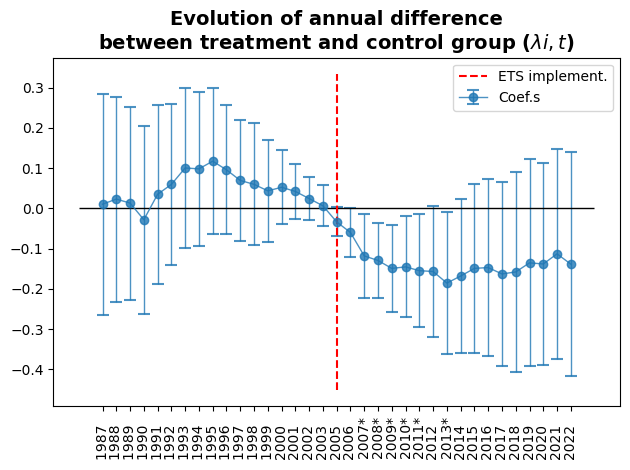

In [299]:
# Fixed code - properly extracts years from complex statsmodels labels

fig, ax = plt.subplots()
ax.set_title("Evolution of annual difference\n"+r"between treatment and control group ($\lambda{i,t}$)", fontsize=14, fontweight="bold")

# Better regex to match full statsmodels label format
ref_pattern = r'C\(year, Treatment\(reference=2004\)\)\[T\.(\d{4})\]'
coefs = parallel_linear_model.params[parallel_linear_model.params.index.str.contains(ref_pattern, regex=True, na=False)]

# Extract years robustly
years_matches = coefs.index.str.extract(ref_pattern, expand=False)
years = pd.to_numeric(years_matches, errors='coerce').dropna().astype(int).values
y_pos = np.arange(len(years))

pvals = parallel_linear_model.pvalues[coefs.index]
conf_int = parallel_linear_model.conf_int()
lower = conf_int.loc[coefs.index, 0].values
upper = conf_int.loc[coefs.index, 1].values
yerr = [coefs.values - lower, upper - coefs.values]

errors = ax.errorbar(y_pos, coefs.values, 
                     yerr=yerr,
                     fmt='o-', capsize=4, capthick=1.5, linewidth=1, 
                     markersize=6, alpha=0.8, label="Coef.s")

years_ticks = [f"{year}*" if p < 0.05 else f"{year}  " for year, p in zip(years, pvals.values)]
ax.set_xticks(y_pos, years_ticks, rotation=90)

ax.hlines(0, ax.get_xlim()[0], ax.get_xlim()[1], color="black", linewidth=1)
ax.vlines(np.where(years==2005)[0], ax.get_ylim()[0], ax.get_ylim()[1], 
          color="red", linestyles="dashed", label="ETS implement.")
ax.legend()
plt.tight_layout()
plt.show()


## DiD Analysis

In [300]:
formula_did = "np.log1p(co2) ~ np.log1p(gdp) + C(year) + C(country) + treated:post_treatment"

did_linear_model = smf.wls(formula=formula_did,
                                weights=1 / df_did_agg.loc[mask, "population"],
                                data=df_did_agg.loc[mask]).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_did_agg.loc[mask, "country"]}
)

#we have to correct for heteroscedasticity

In [301]:
print(did_linear_model.summary())

                            WLS Regression Results                            
Dep. Variable:          np.log1p(co2)   R-squared:                       0.980
Model:                            WLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     1770.
Date:                Tue, 10 Feb 2026   Prob (F-statistic):           2.25e-63
Time:                        16:26:36   Log-Likelihood:                -127.76
No. Observations:                1728   AIC:                             425.5
Df Residuals:                    1643   BIC:                             889.2
Df Model:                          84                                         
Covariance Type:              cluster                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

c:\Users\vetle\anaconda3\envs\finance\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 84, but rank is 37
  warnings.warn('covariance of constraints does not have full '


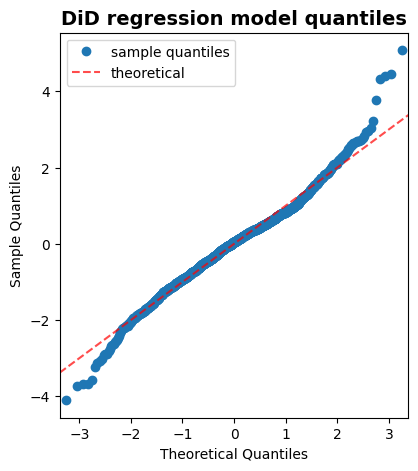

In [302]:
y_hat = did_linear_model.predict(df_did_agg.loc[mask])
y     = df_did_agg.loc[mask, "log_co2"]
probplot = sm.ProbPlot(y-y_hat, fit=True) 

fig,ax = plt.subplots(figsize=(4.5,5))
probplot.qqplot(ax=ax, label="sample quantiles")

ax.axline((0, 0), slope=1, color="red", linestyle="--", alpha=0.7, label="theoretical")
ax.set_title("DiD regression model quantiles", fontsize=14, fontweight="bold")
plt.legend()
plt.show()

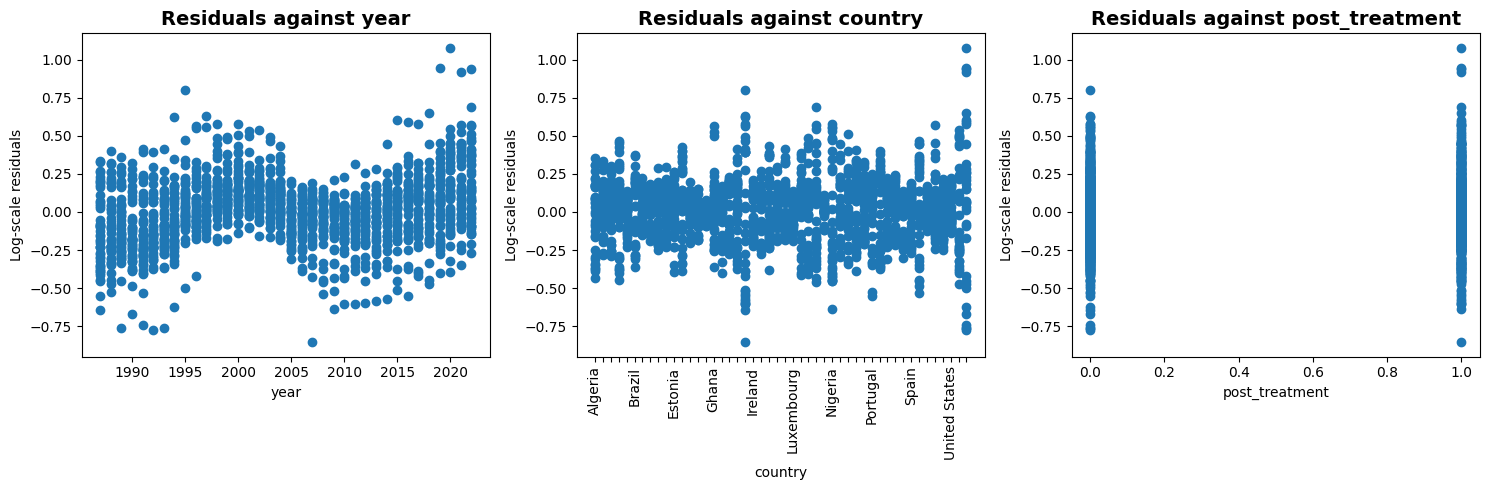

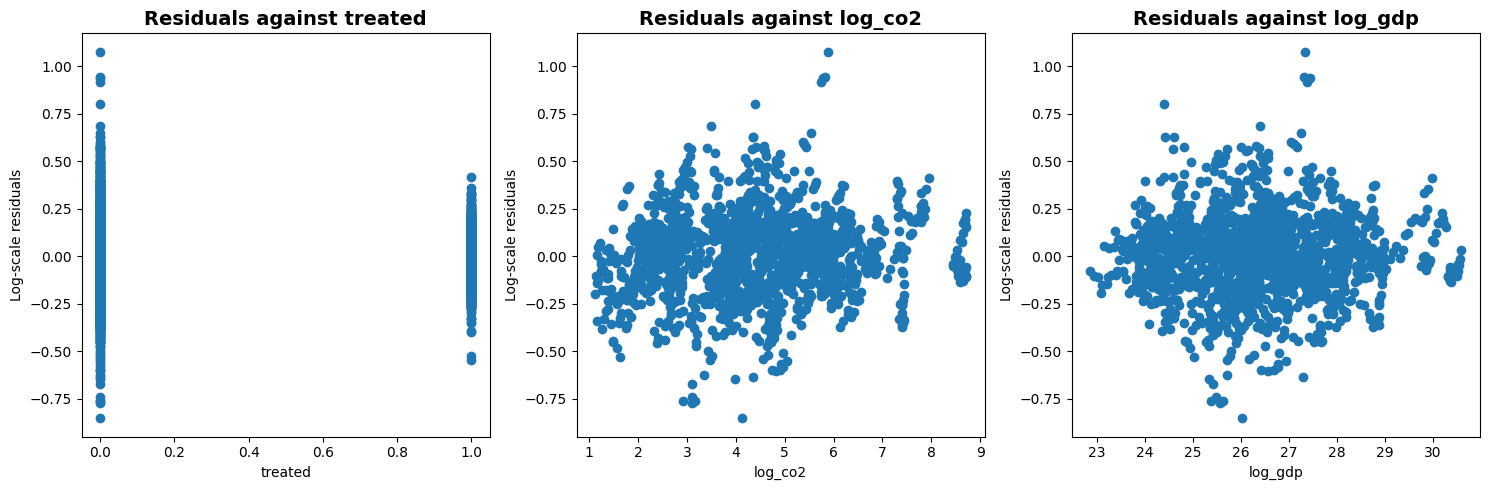

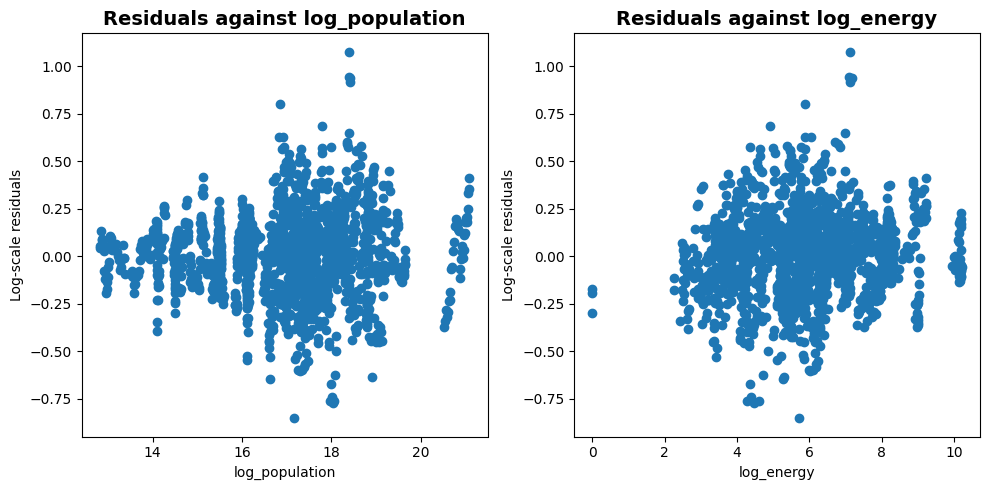

In [303]:
import math

cols = df_did_agg.columns.to_list()
cols = [c for c in cols if c not in ["co2", "population", "gdp", "energy"]]
residuals = did_linear_model.resid

n = len(cols)
num_figs = math.ceil(n / 3)

for i in range(num_figs):
    group = cols[i*3 : (i+1)*3]
    k = len(group)

    fig, axs = plt.subplots(1, k, figsize=(5*k, 5))
    if k == 1:
        axs = [axs]

    for ax, col in zip(axs, group):
        assert len(df_did_agg.loc[mask, col]) == len(residuals)
        ax.scatter(df_did_agg.loc[mask, col], residuals)
        ax.set_title(f"Residuals against {col}", fontsize=14, fontweight="bold")
        ax.set_xlabel(col)
        ax.set_ylabel("Log-scale residuals")
        if col=="country":
            ticks = ax.get_xticks()
            labels = ax.get_xticklabels()
            new_labels = [label if tick%5==0 else "" for label, tick in zip(labels, ticks)]
            ax.set_xticks(ticks, new_labels, rotation=90)

    plt.tight_layout()
    plt.show()
